# Classical Router Training (CE + KL)

This notebook trains a VLM router using **classical multi-class classification** approach.

## Approach

Standard classification with both hard and soft labels:
- **Hard labels**: Best model per (sample, mode) - used for Cross-Entropy (CE) loss
- **Soft labels**: Probability distribution over models from teacher - used for KL divergence
- **Combined loss**: L = α * CE + (1-α) * KL

## Benefits

- **Simple & interpretable**: Standard classification framework
- **Calibrated probabilities**: Softmax outputs give model selection confidence
- **Knowledge distillation**: Soft labels capture relative model performance
- **Well-studied**: Extensive literature on classification + distillation

## Sections

1. Setup & Configuration
2. Load Data from SQL
3. Compute Rewards & Create Labels
4. Build Classification Dataset
5. Train Classical Router
6. Evaluate & Compare to Oracle
7. Visualizations

## 1. Setup & Configuration

In [1]:
# === Path Setup ===
import sys
from pathlib import Path

# Notebook paths
NOTEBOOK_DIR = Path.cwd()
ARTEMIS_DIR = NOTEBOOK_DIR.parent.parent  # artemis_final/
ROOT_DIR = ARTEMIS_DIR.parent             # Which_VLM_Router/
ROUTER_TRAIN_DIR = ARTEMIS_DIR / 'router_train'

# Add to sys.path for imports
for p in [str(ARTEMIS_DIR), str(ROOT_DIR), str(ROUTER_TRAIN_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f"📁 Setup complete")

# Add artemis_final to path
# Also add router_train for local imports

import logging
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

# Local imports
from config import DBConfig, RewardWeights
from db_utils import load_profiles_real_schema, load_from_sqlite, test_connection
from reward_definitions import compute_rewards_real_schema
from models.classical_router import ClassicalRouterModel, create_soft_labels_from_metrics

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


/home/hice1/vchopra37/scratch/projects/vlm_router/vlm_router_env/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


✓ Imports successful
PyTorch version: 2.9.1+cu128
CUDA available: True


In [2]:
# Configuration
LIMIT = 1000  # Set to None for full dataset, or use small number for testing
DATA_SPLIT = "train"  # Load only training data

# Loss settings
TEMPERATURE = 2.0  # Temperature for soft labels (higher = softer)
ALPHA = 0.5  # Weight for CE loss (1-alpha for KL loss)

# Training settings
BATCH_SIZE = 16
NUM_EPOCHS = 5
LEARNING_RATE = 2e-5
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Paths
DATA_DIR = Path("../data")
MODELS_DIR = Path("../models/checkpoints")
DATA_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True, parents=True)

print("Configuration:")
print(f"  LIMIT: {LIMIT}")
print(f"  DATA_SPLIT: {DATA_SPLIT}")
print(f"  TEMPERATURE: {TEMPERATURE}")
print(f"  ALPHA (CE weight): {ALPHA}")
print(f"  BATCH_SIZE: {BATCH_SIZE}")
print(f"  NUM_EPOCHS: {NUM_EPOCHS}")
print(f"  LEARNING_RATE: {LEARNING_RATE}")
print(f"  DEVICE: {DEVICE}")

Configuration:
  LIMIT: 1000
  DATA_SPLIT: train
  TEMPERATURE: 2.0
  ALPHA (CE weight): 0.5
  BATCH_SIZE: 16
  NUM_EPOCHS: 5
  LEARNING_RATE: 2e-05
  DEVICE: cuda


## 2. Load Data from SQL

In [3]:
# # Load database configuration
# db_config = DBConfig.from_env()

# # Test connection
# print("Testing database connection...")
# if test_connection(db_config):
#     print("✓ Database connection successful")
# else:
#     raise RuntimeError("Database connection failed. Check credentials.")

In [6]:
# Load profiling data (SQLite cache preferred)
USE_SQLITE_CACHE = True  # Set False to force PostgreSQL
SQLITE_DB_PATH = Path("../data") / "vlm_router_cache.db"
SQLITE_TABLE_NAME = "vlm_profiles"

print(f"Loading profiling data (data_split={DATA_SPLIT}, limit={LIMIT})...")

df_profiles = None
if USE_SQLITE_CACHE and SQLITE_DB_PATH.exists():
    print(f"  Source: SQLite -> {SQLITE_DB_PATH} ({SQLITE_TABLE_NAME})")
    df_profiles = load_from_sqlite(
        db_path=SQLITE_DB_PATH,
        table_name=SQLITE_TABLE_NAME,
        data_split=DATA_SPLIT,
        limit=LIMIT,
    )
else:
    if USE_SQLITE_CACHE:
        print(f"  SQLite file not found at {SQLITE_DB_PATH}, falling back to DB")
    print(f"  Source: PostgreSQL -> {db_config.host}:{db_config.port}/{db_config.name}")
    df_profiles = load_profiles_real_schema(
        db_config=db_config,
        limit=LIMIT,
        data_split=DATA_SPLIT,
    )

print(f"✓ Loaded {len(df_profiles)} profile records")
print(f"  Unique samples: {df_profiles['sample_id'].nunique()}")
print(f"  Unique models: {df_profiles['model_name'].nunique()}")
print(f"  Models: {sorted(df_profiles['model_name'].unique())}")

# Show sample
df_profiles.head()


2025-12-06 17:21:25,450 - db_utils - INFO - Created SQLite engine for ../data/vlm_router_cache.db
2025-12-06 17:21:25,450 - db_utils - INFO - Loading from ../data/vlm_router_cache.db:vlm_profiles
2025-12-06 17:21:25,450 - db_utils - INFO -   Filtering by data_split: train
2025-12-06 17:21:25,451 - db_utils - INFO -   Limit: 1000
2025-12-06 17:21:25,460 - db_utils - INFO - Loaded 750 rows
2025-12-06 17:21:25,460 - db_utils - INFO -   Unique samples: 193
2025-12-06 17:21:25,461 - db_utils - INFO -   Unique models: 5
2025-12-06 17:21:25,461 - db_utils - INFO -   Data splits: {'train': 750}


Loading profiling data (data_split=train, limit=1000)...
  Source: SQLite -> ../data/vlm_router_cache.db (vlm_profiles)
✓ Loaded 750 profile records
  Unique samples: 193
  Unique models: 5
  Models: ['deepseek_ocr', 'gemma_3_27b', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking']


,sample_id,source_config,source_dataset,router_task,data_split,prompt_raw,txt_prompt_length_chars,txt_prompt_length_words,img_width,img_height,img_aspect_ratio,model_name,model_prefix,latency_ms,cost_usd,confidence_score,glider_score
0,chart2text_0_816f6148,chart2text,cauldron,chart_captioning,train,Please clarify the meaning conveyed by this gr...,50,8,800,557,1.436266,gemma_3_27b,m5,5217.0,0.000061,0.883319,4.0
1,chart2text_0_816f6148,chart2text,cauldron,chart_captioning,train,Please clarify the meaning conveyed by this gr...,50,8,800,557,1.436266,qwen2_5_vl_3b,m2,2239.0,0.000087,0.882716,4.0
2,chart2text_0_816f6148,chart2text,cauldron,chart_captioning,train,Please clarify the meaning conveyed by this gr...,50,8,800,557,1.436266,qwen3_vl_8b_thinking,m4,4928.0,0.001156,0.906978,4.0
3,chart2text_0_816f6148,chart2text,cauldron,chart_captioning,train,Please clarify the meaning conveyed by this gr...,50,8,800,557,1.436266,qwen2_5_vl_7b,m3,2663.0,0.000168,0.874901,4.0
4,chart2text_0_a549e890,chart2text,cauldron,chart_captioning,train,Can you break down the data visualization and ...,66,11,800,557,1.436266,qwen2_5_vl_3b,m2,4327.0,0.000066,0.741361,0.0


## 3. Compute Rewards & Create Labels

In [7]:
# Compute multi-objective rewards
print("\nComputing rewards...")

reward_weights = RewardWeights()  # Use defaults
df_with_rewards = compute_rewards_real_schema(df_profiles, reward_weights)

print(f"✓ Computed rewards for {len(df_with_rewards)} records")
print("\nReward columns:")
reward_cols = [c for c in df_with_rewards.columns if c.startswith('reward_')]
print(reward_cols)

# Show reward statistics
print("\nReward statistics:")
print(df_with_rewards[reward_cols].describe())

2025-12-06 17:21:25,477 - reward_definitions - INFO - Computing rewards for all modes (using real schema with glider_score)...
2025-12-06 17:21:25,480 - reward_definitions - INFO - Using glider_score as primary accuracy (mean=0.658)
2025-12-06 17:21:25,482 - reward_definitions - INFO - Cost normalized: quantile=0.001229, mean=0.235
2025-12-06 17:21:25,483 - reward_definitions - INFO - Latency normalized: quantile=11474.85ms, mean=0.251
2025-12-06 17:21:25,483 - reward_definitions - INFO - Hallucination cleanliness H set to 1.0 (no hallucination signal available)
2025-12-06 17:21:25,485 - reward_definitions - INFO - Using confidence_score as C (mean=0.860)
2025-12-06 17:21:25,485 - reward_definitions - INFO - Reward (accuracy): mean=0.580, std=0.364
2025-12-06 17:21:25,486 - reward_definitions - INFO - Reward (cheap): mean=0.514, std=0.451
2025-12-06 17:21:25,487 - reward_definitions - INFO - Reward (fast): mean=0.507, std=0.429
2025-12-06 17:21:25,488 - reward_definitions - INFO - Rewa


Computing rewards...
✓ Computed rewards for 750 records

Reward columns:
['reward_accuracy', 'reward_cheap', 'reward_fast', 'reward_balanced']

Reward statistics:
       reward_accuracy  reward_cheap  reward_fast  reward_balanced
count       750.000000    750.000000   750.000000       750.000000
mean          0.580373      0.513658     0.506720         0.722115
std           0.363773      0.450759     0.428956         0.400175
min           0.000000     -0.700000    -0.700000        -0.235062
25%           0.640000      0.100000     0.100000         0.466058
50%           0.640000      0.731675     0.674565         0.822772
75%           1.000000      0.793560     0.794888         0.965145
max           1.000000      0.998821     0.998165         1.293901


In [8]:
# Expand to include all 4 modes
print("\nExpanding dataset to include all 4 routing modes...")

modes = ['accuracy', 'cheap', 'fast', 'balanced']
expanded_rows = []

for _, row in df_with_rewards.iterrows():
    for mode in modes:
        row_dict = row.to_dict()
        row_dict['mode_id'] = mode
        row_dict['reward'] = row[f'reward_{mode}']
        expanded_rows.append(row_dict)

df_expanded = pd.DataFrame(expanded_rows)

print(f"✓ Expanded to {len(df_expanded)} rows ({len(df_with_rewards)} → {len(df_expanded)})")
print(f"  Rows per mode: {len(df_expanded) // 4}")

df_expanded.head()


Expanding dataset to include all 4 routing modes...
✓ Expanded to 3000 rows (750 → 3000)
  Rows per mode: 750


,sample_id,source_config,source_dataset,router_task,data_split,prompt_raw,txt_prompt_length_chars,txt_prompt_length_words,img_width,img_height,...,cost_norm,lat_norm,H,C,reward_accuracy,reward_cheap,reward_fast,reward_balanced,mode_id,reward
0,chart2text_0_816f6148,chart2text,cauldron,chart_captioning,train,Please clarify the meaning conveyed by this gr...,50,8,800,557,...,0.049519,0.454646,1.0,0.883319,0.64,0.780997,0.528164,0.784900,accuracy,0.640000
1,chart2text_0_816f6148,chart2text,cauldron,chart_captioning,train,Please clarify the meaning conveyed by this gr...,50,8,800,557,...,0.049519,0.454646,1.0,0.883319,0.64,0.780997,0.528164,0.784900,cheap,0.780997
2,chart2text_0_816f6148,chart2text,cauldron,chart_captioning,train,Please clarify the meaning conveyed by this gr...,50,8,800,557,...,0.049519,0.454646,1.0,0.883319,0.64,0.780997,0.528164,0.784900,fast,0.528164
3,chart2text_0_816f6148,chart2text,cauldron,chart_captioning,train,Please clarify the meaning conveyed by this gr...,50,8,800,557,...,0.049519,0.454646,1.0,0.883319,0.64,0.780997,0.528164,0.784900,balanced,0.784900
4,chart2text_0_816f6148,chart2text,cauldron,chart_captioning,train,Please clarify the meaning conveyed by this gr...,50,8,800,557,...,0.071114,0.195122,1.0,0.882716,0.64,0.770661,0.701493,0.855769,accuracy,0.640000


In [9]:
# Create model and mode mappings
unique_models = sorted(df_expanded['model_name'].unique())
unique_modes = sorted(df_expanded['mode_id'].unique())

model_to_id = {model: i for i, model in enumerate(unique_models)}
id_to_model = {i: model for model, i in model_to_id.items()}

mode_to_id = {mode: i for i, mode in enumerate(unique_modes)}
id_to_mode = {i: mode for mode, i in mode_to_id.items()}

print(f"Models ({len(model_to_id)}): {model_to_id}")
print(f"Modes ({len(mode_to_id)}): {mode_to_id}")

# Save mappings
with open(DATA_DIR / "model_index_classical.json", "w") as f:
    json.dump(model_to_id, f, indent=2)
with open(DATA_DIR / "mode_index_classical.json", "w") as f:
    json.dump(mode_to_id, f, indent=2)

print("\n✓ Saved model and mode index mappings")

Models (5): {'deepseek_ocr': 0, 'gemma_3_27b': 1, 'qwen2_5_vl_3b': 2, 'qwen2_5_vl_7b': 3, 'qwen3_vl_8b_thinking': 4}
Modes (4): {'accuracy': 0, 'balanced': 1, 'cheap': 2, 'fast': 3}

✓ Saved model and mode index mappings


In [10]:
# Create per-(sample, mode) dataset with hard labels
print("\nCreating per-sample dataset with hard labels...")

# Group by (sample_id, mode_id) and find best model
per_sample_data = []

grouped = df_expanded.groupby(['sample_id', 'mode_id'])

for (sample_id, mode_id), group in grouped:
    # Best model (hard label)
    best_idx = group['reward'].idxmax()
    best_model = group.loc[best_idx, 'model_name']
    best_reward = group.loc[best_idx, 'reward']
    
    # Sample metadata (same for all models)
    sample_row = group.iloc[0]
    
    per_sample_data.append({
        'sample_id': sample_id,
        'mode_id': mode_id,
        'best_model': best_model,
        'best_reward': best_reward,
        'prompt_raw': sample_row['prompt_raw'],
        'txt_prompt_length_chars': sample_row.get('txt_prompt_length_chars'),
        'txt_prompt_length_words': sample_row.get('txt_prompt_length_words'),
        'img_width': sample_row.get('img_width'),
        'img_height': sample_row.get('img_height'),
        'img_aspect_ratio': sample_row.get('img_aspect_ratio'),
        'source_dataset': sample_row.get('source_dataset'),
        'router_task': sample_row.get('router_task'),
        'data_split': sample_row.get('data_split'),
    })

df_per_sample = pd.DataFrame(per_sample_data)

print(f"✓ Created per-sample dataset: {len(df_per_sample)} examples")
print(f"  Unique samples: {df_per_sample['sample_id'].nunique()}")
print(f"  Examples per mode: {len(df_per_sample) // len(modes)}")

df_per_sample.head()


Creating per-sample dataset with hard labels...
✓ Created per-sample dataset: 772 examples
  Unique samples: 193
  Examples per mode: 193


,sample_id,mode_id,best_model,best_reward,prompt_raw,txt_prompt_length_chars,txt_prompt_length_words,img_width,img_height,img_aspect_ratio,source_dataset,router_task,data_split
0,ai2d_0_47e3d3a2,accuracy,qwen2_5_vl_3b,1.000000,Question: What is the correct order of develop...,231,39,541,330,1.639394,cauldron,diagram_reasoning,train
1,ai2d_0_47e3d3a2,balanced,qwen2_5_vl_3b,0.993541,Question: What is the correct order of develop...,231,39,541,330,1.639394,cauldron,diagram_reasoning,train
2,ai2d_0_47e3d3a2,cheap,qwen2_5_vl_3b,0.991280,Question: What is the correct order of develop...,231,39,541,330,1.639394,cauldron,diagram_reasoning,train
3,ai2d_0_47e3d3a2,fast,qwen2_5_vl_3b,0.300000,Question: What is the correct order of develop...,231,39,541,330,1.639394,cauldron,diagram_reasoning,train
4,ai2d_0_756e8c98,accuracy,qwen3_vl_8b_thinking,0.640000,Question: What is on top of the plant?\nChoice...,117,23,617,554,1.113718,cauldron,diagram_reasoning,train


In [11]:
# Create soft labels from reward distributions
print(f"\nCreating soft labels (temperature={TEMPERATURE})...")

soft_labels = create_soft_labels_from_metrics(
    df_per_sample=df_expanded,  # Need all (sample, mode, model) rows
    metric_column='reward',
    temperature=TEMPERATURE,
    model_to_id=model_to_id,
)

print(f"✓ Created soft labels: shape {soft_labels.shape}")
print(f"  Expected shape: ({len(df_per_sample)}, {len(model_to_id)})")

# Verify soft labels are valid probability distributions
print(f"\nSoft label statistics:")
print(f"  Row sums (should be ~1.0): {soft_labels.sum(dim=1).mean():.6f} ± {soft_labels.sum(dim=1).std():.6f}")
print(f"  Min value: {soft_labels.min():.6f}")
print(f"  Max value: {soft_labels.max():.6f}")

# Show example soft label distribution
print(f"\nExample soft label distribution:")
print(soft_labels[0])


Creating soft labels (temperature=2.0)...


2025-12-06 17:21:25,951 - models.classical_router - INFO - Created soft labels: shape torch.Size([772, 5])
2025-12-06 17:21:25,952 - models.classical_router - INFO -   Temperature: 2.0
2025-12-06 17:21:26,000 - models.classical_router - INFO -   Entropy (avg): 1.592


✓ Created soft labels: shape torch.Size([772, 5])
  Expected shape: (772, 5)

Soft label statistics:
  Row sums (should be ~1.0): 1.000000 ± 0.000000
  Min value: 0.111798
  Max value: 0.312331

Example soft label distribution:
tensor([0.1418, 0.1953, 0.2338, 0.2338, 0.1953])


## 4. Build Classification Dataset

In [12]:
# Create PyTorch dataset
class ClassificationDataset(Dataset):
    def __init__(self, df_per_sample, soft_labels, model_to_id, mode_to_id):
        self.df = df_per_sample.reset_index(drop=True)
        self.soft_labels = soft_labels
        self.model_to_id = model_to_id
        self.mode_to_id = mode_to_id
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Build input text
        parts = [f"Prompt: {row['prompt_raw']}"]
        if pd.notna(row.get('txt_prompt_length_chars')):
            parts.append(f"PromptLen: {int(row['txt_prompt_length_chars'])} chars")
        if pd.notna(row.get('img_width')) and pd.notna(row.get('img_height')):
            parts.append(f"Image: {int(row['img_width'])}x{int(row['img_height'])}")
        if pd.notna(row.get('source_dataset')):
            parts.append(f"Dataset: {row['source_dataset']}")
        if pd.notna(row.get('router_task')):
            parts.append(f"Task: {row['router_task']}")
        
        sample_text = " | ".join(parts)
        
        # Hard label
        hard_label = self.model_to_id[row['best_model']]
        
        # Soft label
        soft_label = self.soft_labels[idx]
        
        # Mode ID
        mode_id = self.mode_to_id[row['mode_id']]
        
        return sample_text, mode_id, hard_label, soft_label

# Create dataset
train_dataset = ClassificationDataset(
    df_per_sample=df_per_sample,
    soft_labels=soft_labels,
    model_to_id=model_to_id,
    mode_to_id=mode_to_id,
)

print(f"✓ Created training dataset: {len(train_dataset)} examples")

✓ Created training dataset: 772 examples


In [13]:
# Create collate function
def collate_classification_batch(batch):
    sample_texts, mode_ids, hard_labels, soft_labels = zip(*batch)
    
    return {
        'sample_texts': list(sample_texts),
        'mode_ids': torch.tensor(mode_ids, dtype=torch.long),
        'hard_labels': torch.tensor(hard_labels, dtype=torch.long),
        'soft_labels': torch.stack(soft_labels),
    }

# Create dataloader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_classification_batch,
)

print(f"✓ Created training dataloader: {len(train_loader)} batches")

# Test batch
sample_batch = next(iter(train_loader))
print("\nSample batch keys:", sample_batch.keys())
print("  sample_texts:", len(sample_batch['sample_texts']))
print("  mode_ids:", sample_batch['mode_ids'].shape)
print("  hard_labels:", sample_batch['hard_labels'].shape)
print("  soft_labels:", sample_batch['soft_labels'].shape)

✓ Created training dataloader: 49 batches

Sample batch keys: dict_keys(['sample_texts', 'mode_ids', 'hard_labels', 'soft_labels'])
  sample_texts: 16
  mode_ids: torch.Size([16])
  hard_labels: torch.Size([16])
  soft_labels: torch.Size([16, 5])


## 5. Train Classical Router

In [14]:
# Initialize model
model = ClassicalRouterModel(
    num_models=len(model_to_id),
    num_modes=len(mode_to_id),
    text_encoder_name="distilbert-base-uncased",
    mode_embed_dim=16,
    hidden_dim=256,
    dropout=0.1,
)

model = model.to(DEVICE)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

print(f"\n✓ Initialized model on {DEVICE}")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

2025-12-06 17:21:27,029 - models.classical_router - INFO - Initialized ClassicalRouterModel:
2025-12-06 17:21:27,029 - models.classical_router - INFO -   Models (classes): 5, Modes: 4
2025-12-06 17:21:27,030 - models.classical_router - INFO -   Text encoder: distilbert-base-uncased (dim=768)
2025-12-06 17:21:27,030 - models.classical_router - INFO -   Mode embed: 16
2025-12-06 17:21:27,030 - models.classical_router - INFO -   Hidden dim: 256, Dropout: 0.1



✓ Initialized model on cuda
  Total parameters: 66,597,445
  Trainable parameters: 66,597,445


In [15]:
# Training loop
print(f"\nTraining for {NUM_EPOCHS} epochs...\n")

history = {
    'train_loss': [],
    'ce_loss': [],
    'kl_loss': [],
    'accuracy': [],
}

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    epoch_ce = 0.0
    epoch_kl = 0.0
    epoch_correct = 0
    epoch_total = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    
    for batch in pbar:
        optimizer.zero_grad()
        
        # Move to device
        mode_ids = batch['mode_ids'].to(DEVICE)
        hard_labels = batch['hard_labels'].to(DEVICE)
        soft_labels = batch['soft_labels'].to(DEVICE)
        
        # Forward pass
        loss, loss_dict = model.compute_loss(
            sample_texts=batch['sample_texts'],
            mode_ids=mode_ids,
            hard_labels=hard_labels,
            soft_labels=soft_labels,
            temperature=TEMPERATURE,
            alpha=ALPHA,
        )
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track metrics
        epoch_loss += loss_dict['total_loss']
        epoch_ce += loss_dict['ce_loss']
        epoch_kl += loss_dict.get('kl_loss', 0.0)
        
        # Compute accuracy
        with torch.no_grad():
            predictions, _ = model.predict(batch['sample_texts'], mode_ids)
            correct = (predictions == hard_labels).sum().item()
            epoch_correct += correct
            epoch_total += len(hard_labels)
        
        pbar.set_postfix({
            'loss': f"{loss_dict['total_loss']:.4f}",
            'ce': f"{loss_dict['ce_loss']:.4f}",
            'kl': f"{loss_dict.get('kl_loss', 0.0):.4f}",
            'acc': f"{100 * correct / len(hard_labels):.1f}%",
        })
    
    # Epoch statistics
    avg_loss = epoch_loss / len(train_loader)
    avg_ce = epoch_ce / len(train_loader)
    avg_kl = epoch_kl / len(train_loader)
    accuracy = 100 * epoch_correct / epoch_total
    
    history['train_loss'].append(avg_loss)
    history['ce_loss'].append(avg_ce)
    history['kl_loss'].append(avg_kl)
    history['accuracy'].append(accuracy)
    
    print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, CE = {avg_ce:.4f}, KL = {avg_kl:.4f}, Acc = {accuracy:.2f}%")

print("\n✓ Training complete")


Training for 5 epochs...



Epoch 1/5:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 1: Loss = 0.7366, CE = 1.4563, KL = 0.0169, Acc = 33.55%


Epoch 2/5:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 2: Loss = 0.7043, CE = 1.3787, KL = 0.0299, Acc = 37.18%


...

Epoch 3: Loss = 0.6623, CE = 1.2956, KL = 0.0289, Acc = 47.54%


Epoch 4/5:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 4: Loss = 0.6103, CE = 1.1865, KL = 0.0340, Acc = 58.03%


Epoch 5/5:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 5: Loss = 0.5582, CE = 1.0725, KL = 0.0440, Acc = 66.06%

✓ Training complete


In [16]:
# Save trained model
model_path = MODELS_DIR / "best_classical_router.pt"
torch.save({
    'model_state_dict': model.state_dict(),
    'model_to_id': model_to_id,
    'mode_to_id': mode_to_id,
    'config': {
        'num_models': len(model_to_id),
        'num_modes': len(mode_to_id),
        'text_encoder_name': 'distilbert-base-uncased',
        'mode_embed_dim': 16,
        'hidden_dim': 256,
        'dropout': 0.1,
    },
}, model_path)

print(f"✓ Saved model to {model_path}")

✓ Saved model to ../models/checkpoints/best_classical_router.pt


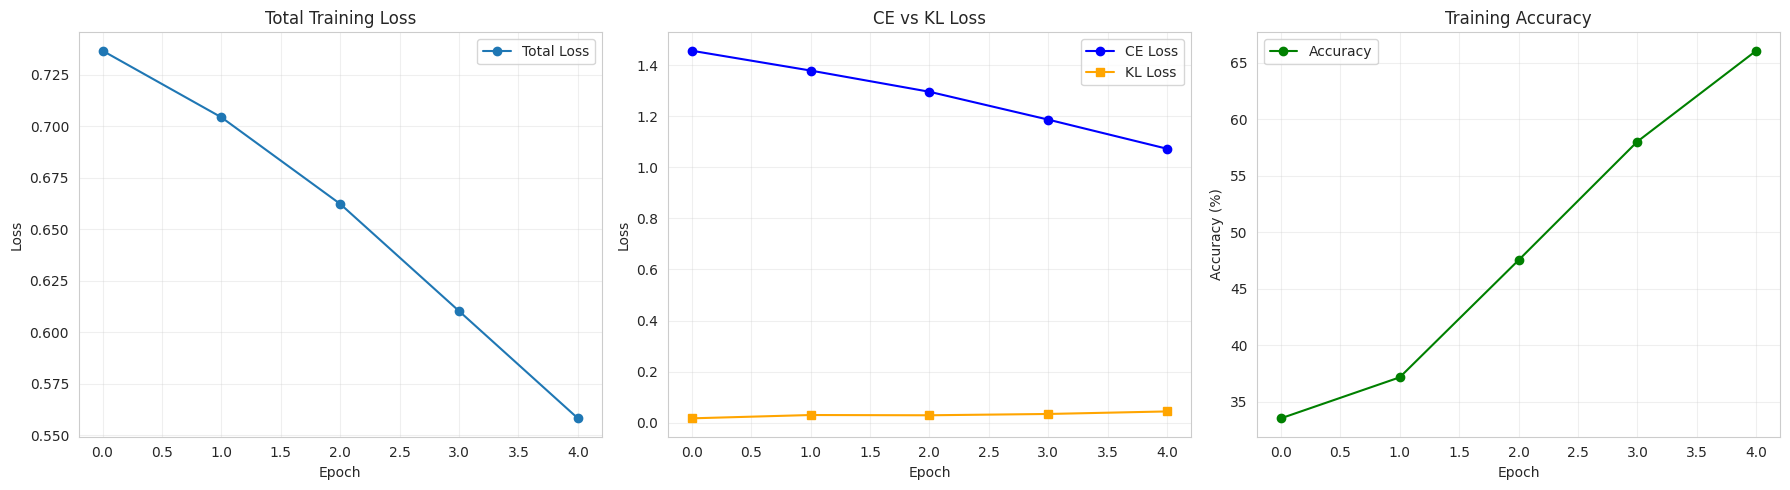

In [17]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total loss
axes[0].plot(history['train_loss'], marker='o', label='Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Total Training Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# CE vs KL
axes[1].plot(history['ce_loss'], marker='o', label='CE Loss', color='blue')
axes[1].plot(history['kl_loss'], marker='s', label='KL Loss', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('CE vs KL Loss')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Accuracy
axes[2].plot(history['accuracy'], marker='o', color='green', label='Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy (%)')
axes[2].set_title('Training Accuracy')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Evaluate & Compare to Oracle

In [18]:
# Load validation data
print("Loading validation data...")

df_val_profiles = None
if USE_SQLITE_CACHE and SQLITE_DB_PATH.exists():
    print(f"  Source: SQLite -> {SQLITE_DB_PATH} ({SQLITE_TABLE_NAME})")
    df_val_profiles = load_from_sqlite(
        db_path=SQLITE_DB_PATH,
        table_name=SQLITE_TABLE_NAME,
        data_split="val",
        limit=500,
    )
else:
    if USE_SQLITE_CACHE:
        print(f"  SQLite file not found at {SQLITE_DB_PATH}, falling back to DB")
    df_val_profiles = load_profiles_real_schema(
        db_config=db_config,
        limit=500,  # Smaller validation set
        data_split="val",
    )

# Compute rewards
df_val_with_rewards = compute_rewards_real_schema(df_val_profiles, reward_weights)

# Expand modes
val_expanded_rows = []
for _, row in df_val_with_rewards.iterrows():
    for mode in modes:
        mode_id = mode_to_id[mode]
        val_expanded_rows.append({
            **row,
            "mode_name": mode,
            "mode_id": mode_id,
            "reward": row[f"reward_{mode}"],
        })

df_val_expanded = pd.DataFrame(val_expanded_rows)


2025-12-06 17:22:29,196 - db_utils - INFO - Created SQLite engine for ../data/vlm_router_cache.db
2025-12-06 17:22:29,196 - db_utils - INFO - Loading from ../data/vlm_router_cache.db:vlm_profiles
2025-12-06 17:22:29,196 - db_utils - INFO -   Filtering by data_split: val
2025-12-06 17:22:29,196 - db_utils - INFO -   Limit: 500
2025-12-06 17:22:29,205 - db_utils - INFO - Loaded 500 rows
2025-12-06 17:22:29,205 - db_utils - INFO -   Unique samples: 129
2025-12-06 17:22:29,205 - db_utils - INFO -   Unique models: 5
2025-12-06 17:22:29,206 - db_utils - INFO -   Data splits: {'val': 500}
2025-12-06 17:22:29,206 - reward_definitions - INFO - Computing rewards for all modes (using real schema with glider_score)...
2025-12-06 17:22:29,208 - reward_definitions - INFO - Using glider_score as primary accuracy (mean=0.658)
2025-12-06 17:22:29,211 - reward_definitions - INFO - Cost normalized: quantile=0.001287, mean=0.257
2025-12-06 17:22:29,211 - reward_definitions - INFO - Latency normalized: qua

Loading validation data...
  Source: SQLite -> ../data/vlm_router_cache.db (vlm_profiles)


In [23]:
# Evaluate routing accuracy vs oracle
print("Evaluating routing accuracy...")

model.eval()
results = []
missing_reward_count = 0

# Helper to resolve mode index whether mode_id is str or int
def _resolve_mode_idx(mode_id_value):
    if mode_id_value in mode_to_id:
        return mode_to_id[mode_id_value]
    try:
        mid_int = int(mode_id_value)
        if mid_int in id_to_mode:
            return mid_int
    except Exception:
        pass
    raise KeyError(f"Unknown mode_id: {mode_id_value}")

# Group by (sample_id, mode_id)
grouped = df_val_expanded.groupby(["sample_id", "mode_id"])

for (sample_id, mode_id), group in tqdm(grouped, desc="Evaluating"):
    mode_idx = _resolve_mode_idx(mode_id)
    mode_name = id_to_mode.get(mode_idx, str(mode_id))
    
    # Oracle choice (best reward)
    oracle_choice = group.loc[group["reward"].idxmax(), "model_name"]
    oracle_reward = group["reward"].max()
    
    # Build input text
    row = group.iloc[0]
    parts = [f"Prompt: {row["prompt_raw"]}"]
    if pd.notna(row.get("txt_prompt_length_chars")):
        parts.append(f"PromptLen: {int(row['txt_prompt_length_chars'])} chars")
    if pd.notna(row.get("img_width")) and pd.notna(row.get("img_height")):
        parts.append(f"Image: {int(row['img_width'])}x{int(row['img_height'])}")
    if pd.notna(row.get("source_dataset")):
        parts.append(f"Dataset: {row['source_dataset']}")
    if pd.notna(row.get("router_task")):
        parts.append(f"Task: {row['router_task']}")
    sample_text = " | ".join(parts)
    
    # Router prediction
    available_models = group["model_name"].tolist()
    available_model_ids = [model_to_id[m] for m in available_models]
    with torch.no_grad():
        predictions, probs = model.predict(
            sample_texts=[sample_text],
            mode_ids=torch.tensor([mode_idx], dtype=torch.long),
        )
        pred_id_raw = predictions[0].item()
        prob_vec = probs[0]
        if pred_id_raw in available_model_ids:
            chosen_id = pred_id_raw
        else:
            # Restrict to available models if prediction not in candidate set
            avail_probs = {mid: prob_vec[mid].item() for mid in available_model_ids}
            chosen_id = max(avail_probs, key=avail_probs.get)
        predicted_model = id_to_model[chosen_id]
        prediction_confidence = prob_vec[chosen_id].item()
    
    # Get router's reward
    matches = group.loc[group["model_name"] == predicted_model, "reward"].values
    if len(matches) == 0:
        missing_reward_count += 1
        router_reward = np.nan
    else:
        router_reward = matches[0]
    
    results.append({
        "sample_id": sample_id,
        "mode_id": mode_idx,
        "mode_name": mode_name,
        "oracle_choice": oracle_choice,
        "oracle_reward": oracle_reward,
        "router_choice": predicted_model,
        "router_reward": router_reward,
        "confidence": prediction_confidence,
        "correct": oracle_choice == predicted_model,
        "reward_gap": oracle_reward - router_reward if not np.isnan(router_reward) else np.nan,
    })

df_results = pd.DataFrame(results)

# Drop rows where router reward missing
if missing_reward_count > 0:
    print(f"Warning: {missing_reward_count} predictions were not in candidate set; using closest available.")
df_results = df_results.dropna(subset=["router_reward", "reward_gap"])

# Print results
overall_acc = 100 * df_results["correct"].mean()
avg_gap = df_results["reward_gap"].mean()
median_gap = df_results["reward_gap"].median()
avg_confidence = df_results["confidence"].mean()

print("" + "="*60)
print("EVALUATION RESULTS")
print("="*60)
print(f"Routing Accuracy: {overall_acc:.2f}%")
print(f"Average Confidence: {avg_confidence:.4f}")
print(f"Average Reward Gap: {avg_gap:.4f}")
print(f"Median Reward Gap: {median_gap:.4f}")
print(f"Oracle Reward (avg): {df_results['oracle_reward'].mean():.4f}")
print(f"Router Reward (avg): {df_results['router_reward'].mean():.4f}")
print("="*60)

# Per-mode breakdown
print("Per-mode breakdown:")
for mode_idx, mode_name in sorted(id_to_mode.items()):
    mode_results = df_results[df_results["mode_id"] == mode_idx]
    mode_acc = 100 * mode_results["correct"].mean()
    mode_gap = mode_results["reward_gap"].mean()
    mode_conf = mode_results["confidence"].mean()
    print(f"  {mode_name:12s}: Acc = {mode_acc:5.2f}%, Gap = {mode_gap:.4f}, Conf = {mode_conf:.4f}")


Evaluating routing accuracy...


Evaluating:   0%|          | 0/516 [00:00<?, ?it/s]

EVALUATION RESULTS
Routing Accuracy: 42.25%
Average Confidence: 0.4747
Average Reward Gap: 0.1900
Median Reward Gap: 0.0000
Oracle Reward (avg): 0.8052
Router Reward (avg): 0.6152
Per-mode breakdown:
  accuracy    : Acc = 33.33%, Gap = 0.1854, Conf = 0.4722
  balanced    : Acc = 45.74%, Gap = 0.1866, Conf = 0.4786
  cheap       : Acc = 56.59%, Gap = 0.1451, Conf = 0.4811
  fast        : Acc = 33.33%, Gap = 0.2427, Conf = 0.4670


## 7. Visualizations

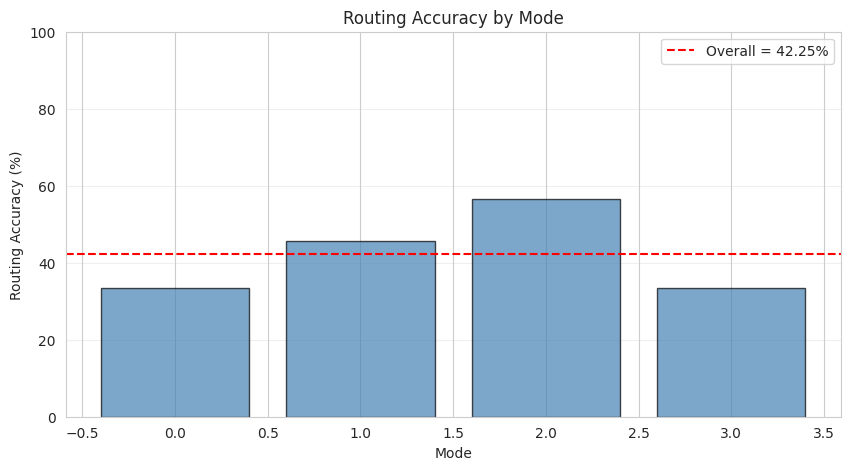

In [24]:
# Routing accuracy by mode
mode_acc = df_results.groupby('mode_id')['correct'].mean() * 100

plt.figure(figsize=(10, 5))
plt.bar(mode_acc.index, mode_acc.values, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Mode')
plt.ylabel('Routing Accuracy (%)')
plt.title('Routing Accuracy by Mode')
plt.axhline(overall_acc, color='red', linestyle='--', label=f'Overall = {overall_acc:.2f}%')
plt.ylim([0, 100])
plt.grid(True, alpha=0.3, axis='y')
plt.legend()
plt.show()

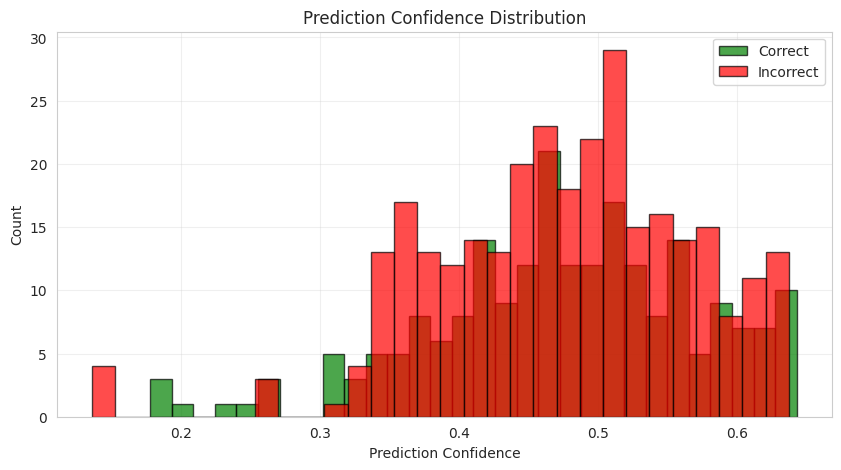

Average confidence (correct): 0.4745
Average confidence (incorrect): 0.4749


In [25]:
# Confidence vs correctness
correct_conf = df_results[df_results['correct'] == True]['confidence']
incorrect_conf = df_results[df_results['correct'] == False]['confidence']

plt.figure(figsize=(10, 5))
plt.hist(correct_conf, bins=30, alpha=0.7, label='Correct', color='green', edgecolor='black')
plt.hist(incorrect_conf, bins=30, alpha=0.7, label='Incorrect', color='red', edgecolor='black')
plt.xlabel('Prediction Confidence')
plt.ylabel('Count')
plt.title('Prediction Confidence Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average confidence (correct): {correct_conf.mean():.4f}")
print(f"Average confidence (incorrect): {incorrect_conf.mean():.4f}")

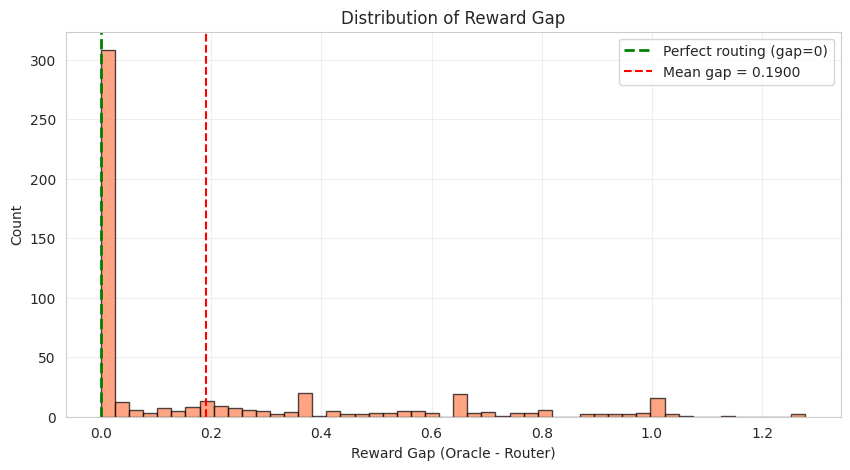


Perfect routing rate: 51.16%


In [26]:
# Reward gap distribution
plt.figure(figsize=(10, 5))
plt.hist(df_results['reward_gap'], bins=50, edgecolor='black', alpha=0.7, color='coral')
plt.xlabel('Reward Gap (Oracle - Router)')
plt.ylabel('Count')
plt.title('Distribution of Reward Gap')
plt.axvline(0, color='green', linestyle='--', linewidth=2, label='Perfect routing (gap=0)')
plt.axvline(avg_gap, color='red', linestyle='--', label=f'Mean gap = {avg_gap:.4f}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

perfect_routing = (df_results['reward_gap'] == 0).mean() * 100
print(f"\nPerfect routing rate: {perfect_routing:.2f}%")

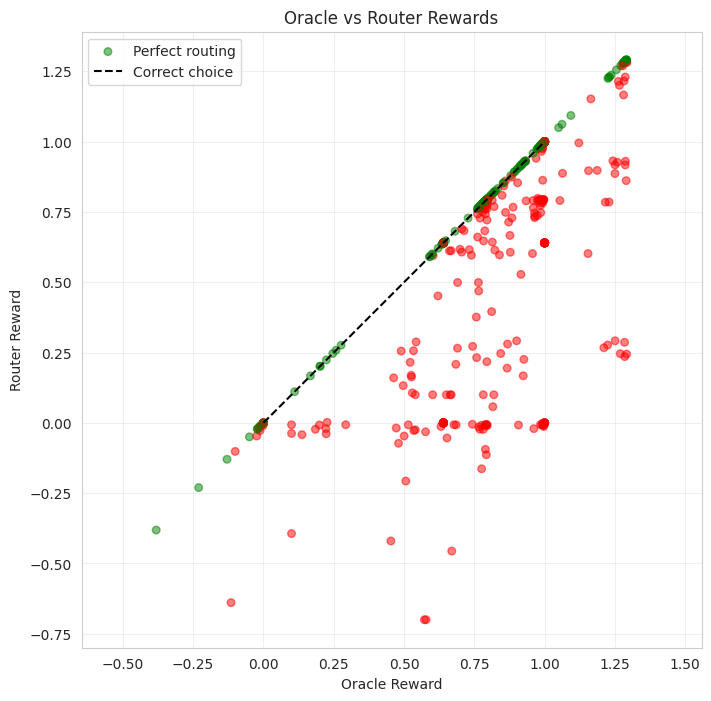

In [27]:
# Oracle vs Router rewards scatter
plt.figure(figsize=(8, 8))
plt.scatter(
    df_results['oracle_reward'],
    df_results['router_reward'],
    alpha=0.5,
    s=30,
    c=df_results['correct'].map({True: 'green', False: 'red'}),
)
plt.plot([0, 1], [0, 1], 'k--', label='Perfect routing')
plt.xlabel('Oracle Reward')
plt.ylabel('Router Reward')
plt.title('Oracle vs Router Rewards')
plt.grid(True, alpha=0.3)
plt.legend(['Perfect routing', 'Correct choice', 'Incorrect choice'])
plt.axis('equal')
plt.show()

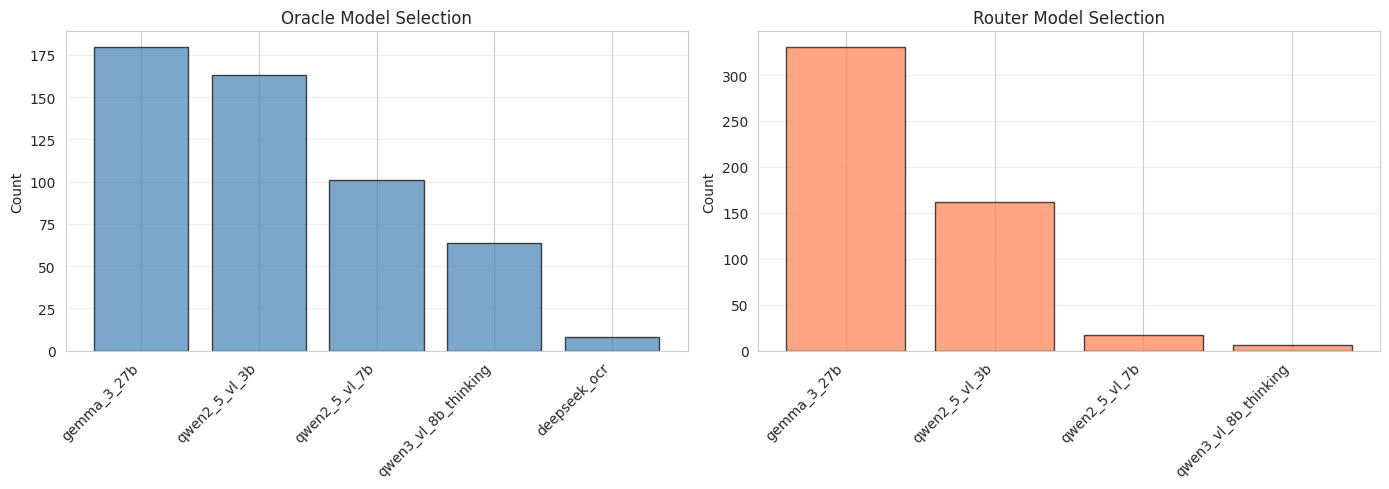

In [28]:
# Model selection distribution
oracle_counts = df_results['oracle_choice'].value_counts()
router_counts = df_results['router_choice'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Oracle
axes[0].bar(range(len(oracle_counts)), oracle_counts.values, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xticks(range(len(oracle_counts)))
axes[0].set_xticklabels(oracle_counts.index, rotation=45, ha='right')
axes[0].set_ylabel('Count')
axes[0].set_title('Oracle Model Selection')
axes[0].grid(True, alpha=0.3, axis='y')

# Router
axes[1].bar(range(len(router_counts)), router_counts.values, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xticks(range(len(router_counts)))
axes[1].set_xticklabels(router_counts.index, rotation=45, ha='right')
axes[1].set_ylabel('Count')
axes[1].set_title('Router Model Selection')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

[PERFORMANCE DIAGNOSTICS]


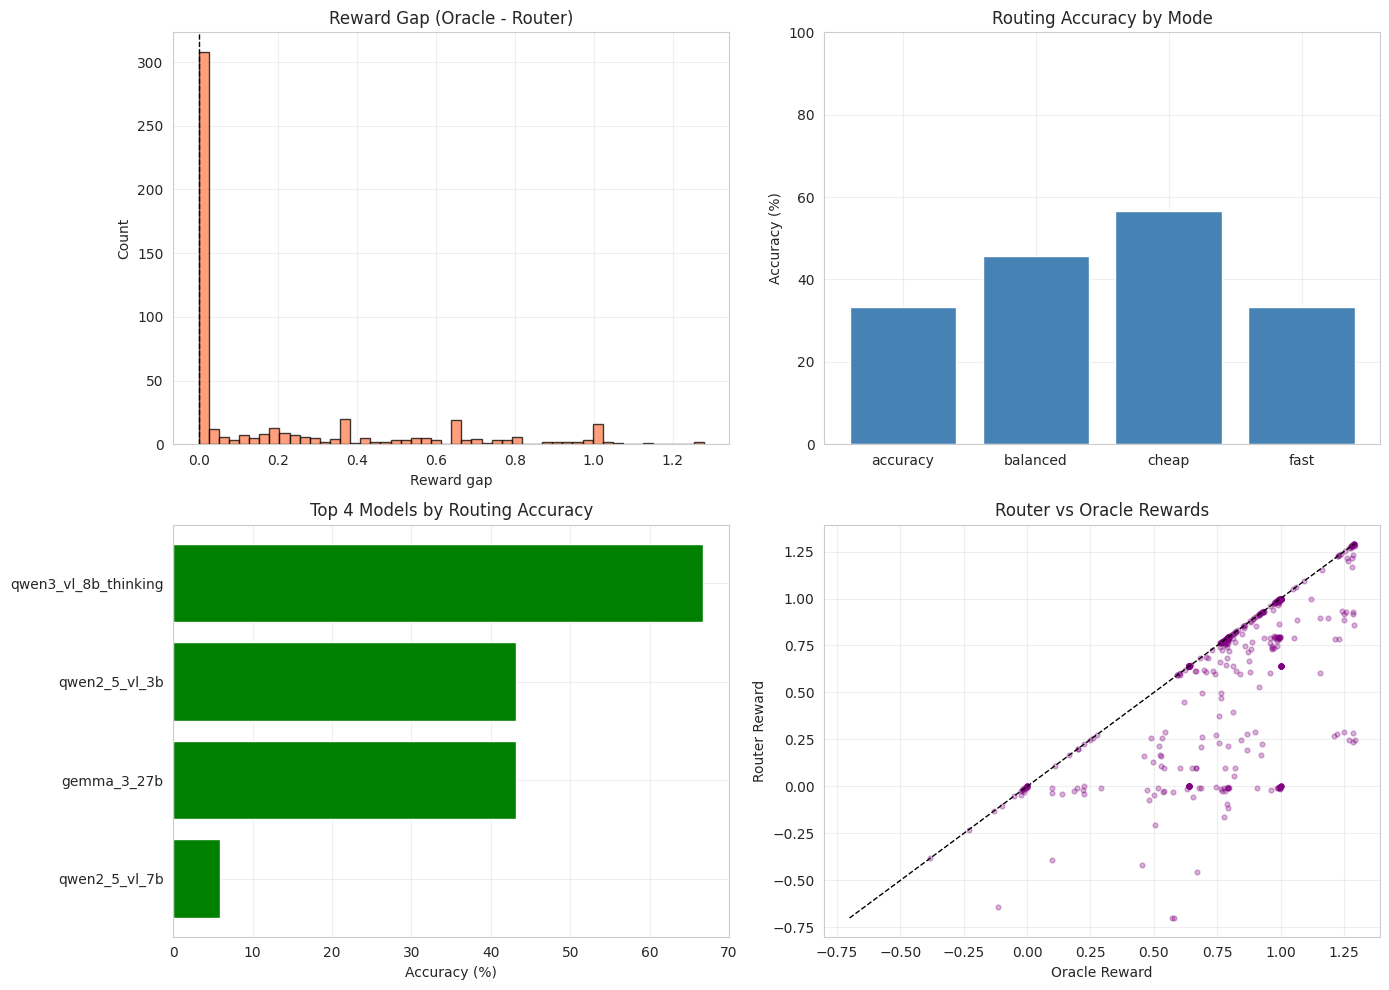

[SUMMARY METRICS]
Overall accuracy: 42.25%
Mean reward gap: 0.1900 | Median: 0.0000
  accuracy     Acc = 33.33% | Gap = 0.1854
  balanced     Acc = 45.74% | Gap = 0.1866
  cheap        Acc = 56.59% | Gap = 0.1451
  fast         Acc = 33.33% | Gap = 0.2427


In [29]:
# Extra diagnostics: reward gaps, accuracy, and per-model stats
print('[PERFORMANCE DIAGNOSTICS]')

reward_gap = df_results['reward_gap']
mode_acc = df_results.groupby('mode_id')['correct'].mean().sort_index()
gap_by_mode = df_results.groupby('mode_id')['reward_gap'].mean().sort_index()
per_model_acc = df_results.groupby('router_choice')['correct'].mean().sort_values(ascending=False)

mode_labels = [id_to_mode[m] if 'id_to_mode' in globals() else str(m) for m in mode_acc.index]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Reward gap histogram
axes[0, 0].hist(reward_gap, bins=50, color='coral', edgecolor='black', alpha=0.75)
axes[0, 0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0, 0].set_title('Reward Gap (Oracle - Router)')
axes[0, 0].set_xlabel('Reward gap')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(alpha=0.3)

# Accuracy by mode
axes[0, 1].bar(mode_labels, mode_acc.values * 100, color='steelblue')
axes[0, 1].set_ylim(0, 100)
axes[0, 1].set_title('Routing Accuracy by Mode')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].grid(alpha=0.3)

# Top models by accuracy
top_n = min(10, len(per_model_acc))
axes[1, 0].barh(per_model_acc.head(top_n).index[::-1], per_model_acc.head(top_n).values[::-1] * 100, color='green')
axes[1, 0].set_title(f'Top {top_n} Models by Routing Accuracy')
axes[1, 0].set_xlabel('Accuracy (%)')
axes[1, 0].grid(alpha=0.3)

# Oracle vs Router rewards scatter
min_r = min(df_results['oracle_reward'].min(), df_results['router_reward'].min())
max_r = max(df_results['oracle_reward'].max(), df_results['router_reward'].max())
axes[1, 1].scatter(df_results['oracle_reward'], df_results['router_reward'], alpha=0.3, s=12, color='purple')
axes[1, 1].plot([min_r, max_r], [min_r, max_r], 'k--', linewidth=1)
axes[1, 1].set_xlabel('Oracle Reward')
axes[1, 1].set_ylabel('Router Reward')
axes[1, 1].set_title('Router vs Oracle Rewards')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('[SUMMARY METRICS]')
print(f"Overall accuracy: {mode_acc.mean() * 100:.2f}%")
print(f"Mean reward gap: {reward_gap.mean():.4f} | Median: {reward_gap.median():.4f}")
mode_info = list(zip(mode_labels, mode_acc.values, gap_by_mode.values))
for label, acc, gap in mode_info:
    print(f"  {label:12s} Acc = {acc*100:5.2f}% | Gap = {gap:.4f}")


## Summary

This notebook demonstrated training a **classical classification router** with CE + KL loss:

### Key Results
- **Training Accuracy**: How well the model predicts hard labels during training
- **Routing Accuracy**: How often the router picks the same model as the oracle
- **Prediction Confidence**: Softmax probability of the predicted model
- **Reward Gap**: Difference between oracle and router rewards

### Comparison to Other Approaches
- **Reward-based (Notebook 02)**: Predicts scalar rewards, then picks highest
- **Pairwise ranking (Notebook 03)**: Learns relative preferences between models
- **Classical (this notebook)**: Direct classification with soft label distillation

### Next Steps
1. **Compare all 3 approaches**: Evaluate on same test set
2. **Tune hyperparameters**: Adjust temperature, alpha, learning rate
3. **Ensemble methods**: Combine multiple router approaches
4. **Production deployment**: Use trained model for real-time routing

### Files Generated
- `../models/checkpoints/best_classical_router.pt` - Trained model
- `../data/model_index_classical.json` - Model ID mappings
- `../data/mode_index_classical.json` - Mode ID mappings